# TRM-RTify — Pareto Sweep (Speed–Accuracy Tradeoff)

This notebook sweeps `theta` over a range of values on a trained TRM-RTify checkpoint,
recording **exact accuracy** and **mean inference steps** at each value.

The result is a **Pareto curve** showing the speed–accuracy tradeoff available at deployment
by simply changing `theta` post-training — no retraining required.

---
**Sections:**
1. Config — set your checkpoint path and theta values here
2. Imports & model loading
3. Data loading
4. Evaluation loop
5. Pareto curve plot
6. Results table

## 1. Config
**Edit this cell only** — everything else runs automatically.

In [81]:
# ── User config ────────────────────────────────────────────────────────────
CHECKPOINT_PATH = "checkpoints/sudoku_baseline/TRM_RTify_long_phi10/best.ckpt"  
DATA_DIR        = "data/sudoku-extreme-1k-aug-1000"                         
SPLIT           = "test"                                        # "test" or "test"
BATCH_SIZE      = 768
DEVICE          = "cuda"   # "cuda" or "cpu"

# Theta values to sweep. Must all be > theta_min (read from checkpoint).
# Add or remove values as needed.
THETA_VALUES = [10.001, 11.0, 12.0, 14.0, 16.0, 20.0, 30.0, 40.0]

# Set to True to run on a small subset for a quick sanity check
DRY_RUN      = False
DRY_RUN_SIZE = 20000   # number of puzzles to use in dry-run mode
# ───────────────────────────────────────────────────────────────────────────

## 2. Imports & Model Loading

In [82]:
import json
import math
import os
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from torch.utils.data import DataLoader, Subset
from IPython.display import display

from models.recursive_reasoning.TRM_RTify import TRM_Rtify, TRMRtifyConfig
from puzzle_dataset import PuzzleDataset, PuzzleDatasetConfig

device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [83]:
ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
print(ckpt["config"].keys())

dict_keys(['arch', 'project_name', 'run_name', 'data_paths', 'data_split_train', 'data_split_eval', 'blank_id', 'global_batch_size', 'max_eval_batches', 'lr', 'lr_min_ratio', 'lr_warmup_steps', 'weight_decay', 'beta1', 'beta2', 'seed', 'epochs', 'eval_interval', 'device', 'checkpoint_dir', 'save_every', 'save_best', 'resume', 'load_checkpoint', 'best_metric', 'best_mode', 'wandb', 'n_reasoning_episodes'])


In [84]:
def load_model(ckpt_path, device):
    ckpt      = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    train_cfg = ckpt["config"]
    arch_cfg  = dict(train_cfg["arch"])  # copy so we don't mutate the ckpt

    epoch = ckpt.get("epoch", 0)
    step  = ckpt.get("step",  0)
    score = ckpt.get("best_score") or 0.0
    print(f"Checkpoint  epoch={epoch}  step={step}  best_score={score:.4f}")

    # Sudoku-Extreme is always 81 cells, vocab 11
    # (0=pad/ignore, 1=blank, 2-10=digits 1-9)
    arch_cfg["seq_len"]    = 81
    arch_cfg["vocab_size"] = 11

    model = TRM_Rtify(arch_cfg)

    # Strip DDP "module." prefix if present
    state = ckpt["model_state"]
    if any(k.startswith("_orig_mod.") for k in state):
        state = {k.removeprefix("_orig_mod."): v for k, v in state.items()}

    missing, unexpected = model.load_state_dict(state, strict=True)
    if missing:     print(f"  WARNING: {len(missing)} missing keys")
    if unexpected:  print(f"  WARNING: {len(unexpected)} unexpected keys")

    model.to(device)
    model.eval()
    print(f"Model loaded  params={sum(p.numel() for p in model.parameters()):,}")
    return model, arch_cfg, train_cfg

model, arch_cfg, train_cfg = load_model(CHECKPOINT_PATH, device)

Checkpoint  epoch=7999  step=197669  best_score=0.7614
Model loaded  params=7,090,189


## 3. Data Loading

In [85]:
ds_cfg = PuzzleDatasetConfig(
    seed=42,
    dataset_paths=[DATA_DIR],
    global_batch_size=BATCH_SIZE,
    test_set_mode=True,
    epochs_per_iter=1,
    rank=0,
    num_replicas=1,
)
dataset = PuzzleDataset(ds_cfg, split=SPLIT)

loader = DataLoader(
    dataset,
    batch_size=None,       # PuzzleDataset already batches internally
    shuffle=False,
    num_workers=1,         # IterableDataset only supports num_workers=1
    pin_memory=(DEVICE == "cuda"),
)

# Dry run: limit number of batches instead of dataset size
MAX_BATCHES = 2 if DRY_RUN else None
print(f"{'DRY RUN: ' + str(DRY_RUN_SIZE) + ' puzzles max' if DRY_RUN else 'Full eval'}")

Full eval


## 4. Evaluation Loop

In [86]:
IGNORE_LABEL = -100


def set_theta(model: TRM_Rtify, theta: float):
    """Override model.psi so that theta_min + Softplus(psi) == theta."""
    theta_min = model.config.theta_min
    assert theta > theta_min, f"theta={theta} must be > theta_min={theta_min}"
    gap = theta - theta_min
    psi = math.log(math.exp(gap) - 1.0)   # Softplus inverse
    model.psi.data.fill_(psi)


@torch.no_grad()
def evaluate(model: TRM_Rtify, loader: DataLoader, theta: float, device: torch.device, max_batches=None) -> dict:
    """Run one full inference pass on the dataset at a fixed theta."""
    original_psi = model.psi.data.clone()
    set_theta(model, theta)

    max_steps     = model.config.halt_max_steps
    total_puzzles = 0
    total_exact   = 0
    total_steps   = 0

    for i, (_, batch, _) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break

        batch  = {k: v.to(device).long() for k, v in batch.items()}
        labels = batch["labels"]    # [B, L]
        B      = labels.shape[0]

        carry = model.initial_carry(batch)

        # ── Episode loop ──────────────────────────────────────────────
        for _ in range(max_steps):
            carry, _ = model(carry, batch)
            if carry.halted.all():
                break

        # ── Exact accuracy ────────────────────────────────────────────
        preds      = carry.last_logits.argmax(dim=-1)          # [B, L]
        blank_mask = labels != IGNORE_LABEL                    # [B, L]
        correct    = (preds == labels) | ~blank_mask           # [B, L]
        exact      = correct.all(dim=-1)                       # [B]

        total_exact   += exact.sum().item()
        total_steps   += carry.steps.float().sum().item()
        total_puzzles += B

    # Restore original psi
    model.psi.data.copy_(original_psi)

    return {
        "theta":          theta,
        "exact_accuracy": total_exact  / total_puzzles,
        "mean_steps":     total_steps  / total_puzzles,
        "total_puzzles":  total_puzzles,
    }

In [ ]:
theta_min = model.config.theta_min
valid_thetas = [t for t in sorted(THETA_VALUES) if t > theta_min]
skipped      = [t for t in THETA_VALUES if t <= theta_min]

if skipped:
    print(f"Skipping theta values <= theta_min ({theta_min}): {skipped}")

results = []
for theta in THETA_VALUES:
    print(f"  theta={theta:5.1f} ...", end="  ", flush=True)
    r = evaluate(model, loader, theta, device, max_batches=MAX_BATCHES)
    results.append(r)
    print(f"exact_acc={r['exact_accuracy']:.4f}   mean_steps={r['mean_steps']:.2f}")

print("\nSweep complete.")

  theta= 10.0 ...  exact_acc=0.7707   mean_steps=5.01
  theta= 11.0 ...  exact_acc=0.7797   mean_steps=5.54
  theta= 12.0 ...  

## 5. Pareto Curve

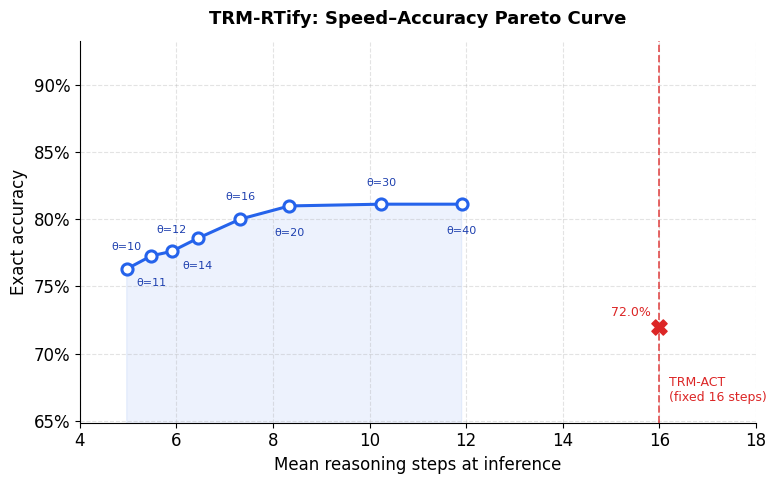

Saved → pareto_curve.png


In [80]:
steps    = [r["mean_steps"]     for r in results]
accuracy = [r["exact_accuracy"] for r in results]
thetas   = [r["theta"]          for r in results]

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":  "sans-serif",
    "font.size":    12,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(8, 5))

# ── Shaded region under curve ─────────────────────────────────────────────
ax.fill_between(steps, accuracy, alpha=0.08, color="#2563eb")

# ── Main line and points ──────────────────────────────────────────────────
ax.plot(
    steps, accuracy,
    "-o",
    color="#2563eb",
    linewidth=2.2,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2.2,
    zorder=3,
)

# ── Theta labels on each point ────────────────────────────────────────────
for i, (s, a, t) in enumerate(zip(steps, accuracy, thetas)):
    dy = 12 if i % 2 == 0 else -16
    va = 'bottom' if i % 2 == 0 else 'top'
    ax.annotate(
        f"θ={t:.0f}",
        xy=(s, a),
        xytext=(0, dy),
        textcoords="offset points",
        fontsize=8,
        color="#1e40af",
        ha='center',
        va=va,
    )

# ── Reference line at M=16 (TRM-ACT always uses this) ────────────────────
ax.axvline(
    x=16, linestyle="--", linewidth=1.4,
    color="#dc2626", alpha=0.7,
)
ax.text(
    16.2, 0.05,
    "TRM-ACT\n(fixed 16 steps)",
    color="#dc2626", fontsize=9, va="bottom",
    transform=ax.get_xaxis_transform(),  # x in data coords, y in axes fraction (0-1)
)
# ── TRM-ACT reference point ───────────────────────────────────────────────
ax.scatter(
    [16], [0.72],
    marker="X",
    s=120,
    color="#dc2626",
    zorder=4,
    label="TRM-ACT (reproduced, no EMA)",
)
ax.annotate(
    "72.0%",
    xy=(16, 0.72),
    xytext=(-35, 8),
    textcoords="offset points",
    fontsize=9,
    color="#dc2626",
)

# ── Axes ──────────────────────────────────────────────────────────────────
ax.set_xlabel("Mean reasoning steps at inference", fontsize=12)
ax.set_ylabel("Exact accuracy", fontsize=12)
ax.set_title("TRM-RTify: Speed–Accuracy Pareto Curve", fontsize=13, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xlim(left=4, right=18)
ax.set_ylim(bottom=min(1.0, min(accuracy) * 0.85), top=min(1.0, max(accuracy) * 1.15))
ax.grid(True, linestyle="--", alpha=0.35, zorder=0)

plt.tight_layout()
plt.savefig("pareto_curve.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved → pareto_curve.png")

## 6. Results Table

In [60]:
df = pd.DataFrame(results)[["theta", "mean_steps", "exact_accuracy", "total_puzzles"]]
df.columns = ["θ", "Mean steps", "Exact accuracy", "Puzzles"]
df["Exact accuracy"] = df["Exact accuracy"].map("{:.2%}".format)
df["Mean steps"]     = df["Mean steps"].map("{:.2f}".format)
df["θ"]              = df["θ"].map("{:.1f}".format)

display(df.style.set_caption("Pareto sweep results").hide(axis="index"))

# Save to JSON for use in the thesis
with open("pareto_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved → pareto_results.json")

θ,Mean steps,Exact accuracy,Puzzles
10.0,4.97,76.30%,1536
11.0,5.48,77.28%,1536
12.0,5.90,77.60%,1536
14.0,6.44,78.58%,1536
16.0,7.32,80.01%,1536
20.0,8.34,80.99%,1536
30.0,10.24,81.12%,1536
40.0,11.90,81.12%,1536


Saved → pareto_results.json


## 7. LaTeX Table (copy into thesis)
Generates the `\begin{table}` block for Chapter 3 directly.

In [ ]:
lines = [
    r"\begin{table}[h]",
    r"\centering",
    r"\caption{TRM-RTify speed--accuracy tradeoff at inference. "
    r"Sweeping $\theta$ post-training gives a continuous Pareto curve "
    r"without any retraining.}",
    r"\label{tab:pareto}",
    r"\begin{tabular}{ccc}",
    r"\toprule",
    r"$\theta$ & Mean steps & Exact accuracy \\\\",
    r"\midrule",
]
for r in results:
    lines.append(
        f"{r['theta']:.1f} & {r['mean_steps']:.2f} & {r['exact_accuracy']:.1%} \\\\"
    )
lines += [
    r"\bottomrule",
    r"\end{tabular}",
    r"\end{table}",
]

latex = "\n".join(lines)
print(latex)